# Real Estate Price Analysis
Exploratory analysis, feature transformation, and multiple linear regression on residential real estate transaction data (Sindian District, New Taipei City).

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
#Viz :
import matplotlib.pyplot as plt
import seaborn as sns
#Models :
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
pd.set_option('display.max_columns', None)

## 2. Load Data

In [2]:
df = pd.read_csv('01_Dataset/01_Real_estate.csv')
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [3]:
df.info()
#No nulls

<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


## 3. Cleaning

In [4]:
#Cleaning columns :
df.columns = df.columns.str.lower().str.strip().str.replace(" ","_")
df.columns

Index(['no', 'x1_transaction_date', 'x2_house_age',
       'x3_distance_to_the_nearest_mrt_station',
       'x4_number_of_convenience_stores', 'x5_latitude', 'x6_longitude',
       'y_house_price_of_unit_area'],
      dtype='str')

In [5]:
df.columns = ['no', 'transaction_date', 'house_age',
       'distance__mrt',
       'convenience_stores', 'latitude', 'longitude',
       'house_price_unit_area']
df.head()

,no,transaction_date,house_age,distance__mrt,convenience_stores,latitude,longitude,house_price_unit_area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [6]:
df.duplicated().sum().sum()

np.int64(0)

In [7]:
df_subset = df.drop(columns = ['no'])
df_subset.head()

,transaction_date,house_age,distance__mrt,convenience_stores,latitude,longitude,house_price_unit_area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [8]:
df_subset.describe()

,transaction_date,house_age,distance__mrt,convenience_stores,latitude,longitude,house_price_unit_area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


## 4. Date Feature Engineering

In [9]:
#Extract year & date :
df_subset['t_year'] = df_subset['transaction_date'].astype(int)

In [10]:
df_subset['t_month'] = np.round((df_subset['transaction_date'] % 1) * 12).astype(int)

In [11]:
df_subset.head()

,transaction_date,house_age,distance__mrt,convenience_stores,latitude,longitude,house_price_unit_area,t_year,t_month
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9,2012,11
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2,2012,11
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3,2013,7
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8,2013,6
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1,2012,10


## 5. Yearly EDA

In [12]:
#EDA :
#Average/Total Sales per unit area per year :
print("---------------------------------------------")
print("Average Sales/Unit Area each Year :")
print("---------------------------------------------")
print(df_subset.groupby('t_year')['house_price_unit_area'].mean())
print("---------------------------------------------")
print("Total Sales/Unit Area each Year:")
print("---------------------------------------------")
print(df_subset.groupby('t_year')['house_price_unit_area'].sum())
#2013 sales are ~~ 2x more then 2012 sales 

---------------------------------------------
Average Sales/Unit Area each Year :
---------------------------------------------
t_year
2012    36.304762
2013    38.713194
Name: house_price_unit_area, dtype: float64
---------------------------------------------
Total Sales/Unit Area each Year:
---------------------------------------------
t_year
2012     4574.4
2013    11149.4
Name: house_price_unit_area, dtype: float64


In [13]:
df_subset.head()

,transaction_date,house_age,distance__mrt,convenience_stores,latitude,longitude,house_price_unit_area,t_year,t_month
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9,2012,11
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2,2012,11
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3,2013,7
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8,2013,6
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1,2012,10


## 6. Month Names

In [14]:
#Create a Month name columns :
import pandas as pd

# 1. Clean '0' values in t_month (replace 0 with 1, or handle invalid months)
df_subset['t_month'] = df_subset['t_month'].replace(0 , 12)
df_subset['month_name'] = pd.to_datetime(df_subset['t_month'] , format = "%m").dt.month_name().str.slice(stop = 3)
df_subset.head()

,transaction_date,house_age,distance__mrt,convenience_stores,latitude,longitude,house_price_unit_area,t_year,t_month,month_name
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9,2012,11,Nov
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2,2012,11,Nov
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3,2013,7,Jul
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8,2013,6,Jun
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1,2012,10,Oct


## 7. Visual EDA

/tmp/ipykernel_556/4218550565.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_subset, x='month_name', y='house_price_unit_area', order=[m for m in month_order if m in df_subset['month_name'].unique()], palette='Blues')


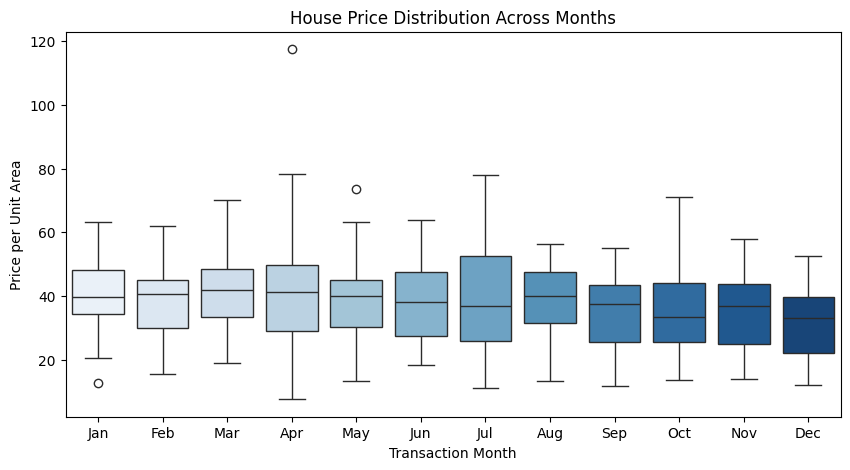

In [15]:
#Create a Box Plot price accross months :
# Sort months chronologically for the plot
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_subset, x='month_name', y='house_price_unit_area', order=[m for m in month_order if m in df_subset['month_name'].unique()], palette='Blues')
plt.title('House Price Distribution Across Months')
plt.xlabel('Transaction Month')
plt.ylabel('Price per Unit Area')
plt.show()

/tmp/ipykernel_556/2597788005.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_subset, x='t_year', y='house_price_unit_area', estimator='mean', errorbar=None, palette='viridis')


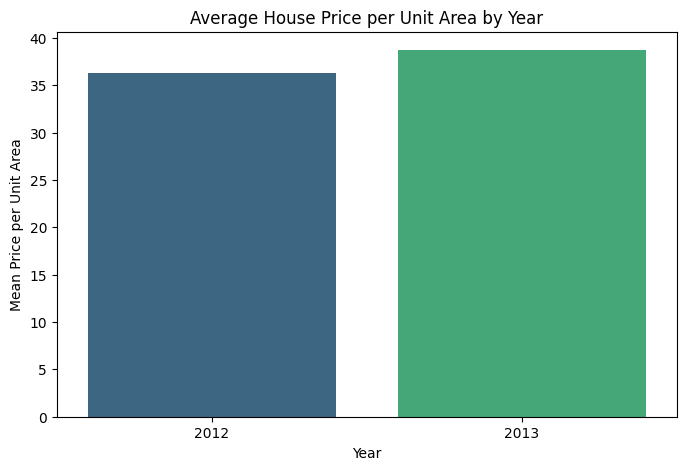

In [16]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_subset, x='t_year', y='house_price_unit_area', estimator='mean', errorbar=None, palette='viridis')
plt.title('Average House Price per Unit Area by Year')
plt.xlabel('Year')
plt.ylabel('Mean Price per Unit Area')
plt.show()

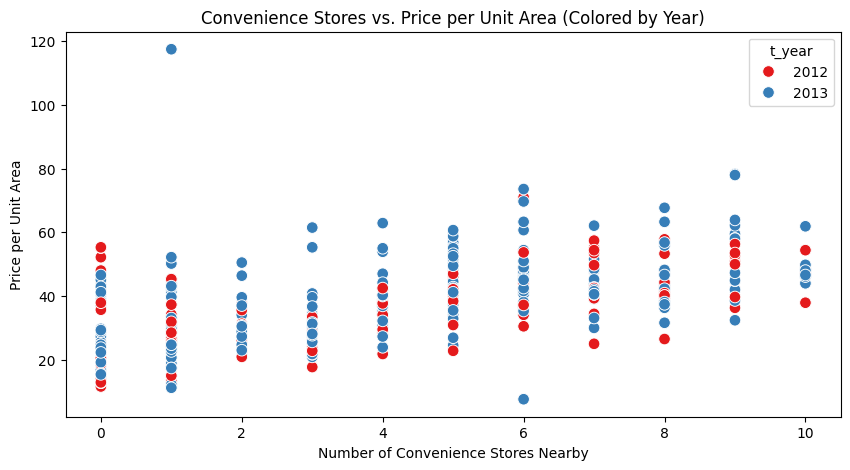

In [17]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_subset, x='convenience_stores', y='house_price_unit_area', hue='t_year', palette='Set1', s=70)
plt.title('Convenience Stores vs. Price per Unit Area (Colored by Year)')
plt.xlabel('Number of Convenience Stores Nearby')
plt.ylabel('Price per Unit Area')
plt.show()

## 8. Pairplot (Before Transformation)
Checking pairwise relationships and linearity before transforming any features.

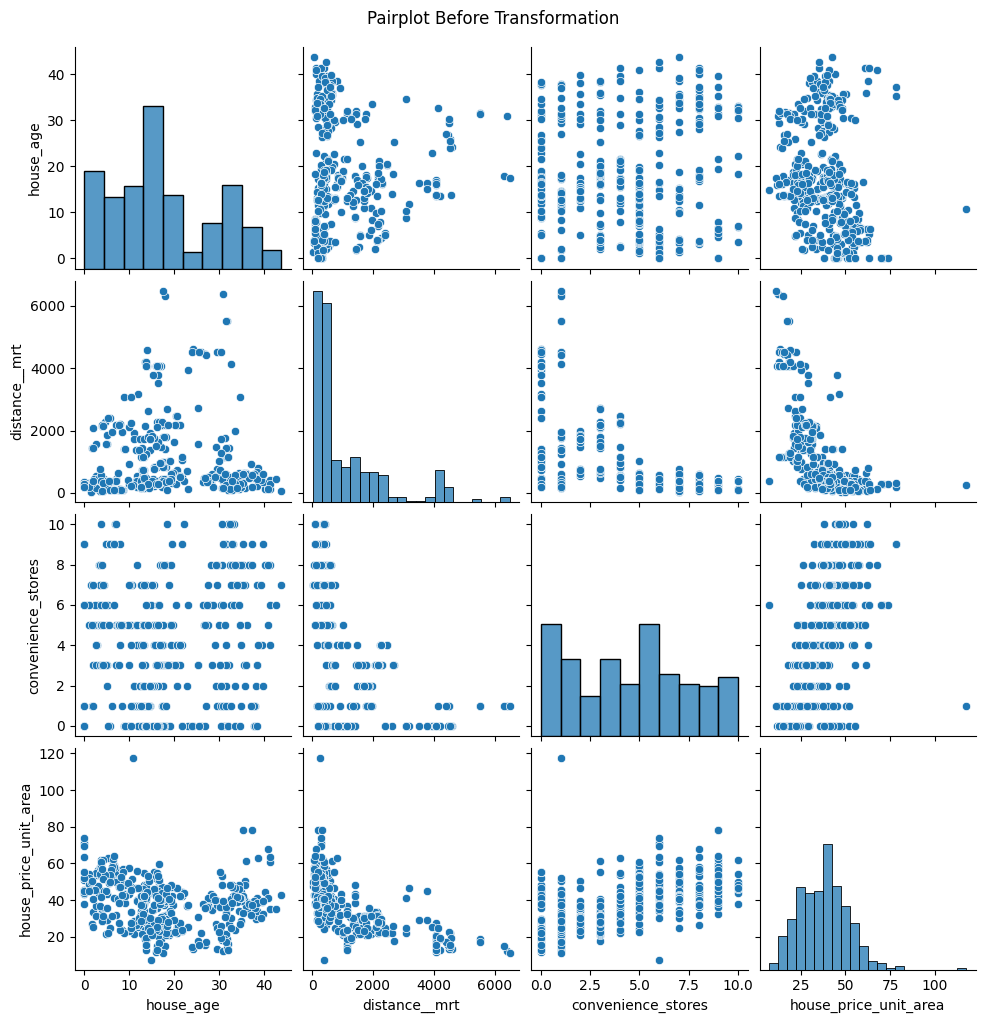

In [18]:
sns.pairplot(df_subset[['house_age','distance__mrt','convenience_stores','house_price_unit_area']])
plt.suptitle('Pairplot Before Transformation', y=1.02)
plt.show()

## 9. Feature Transformation
`distance__mrt` is heavily right-skewed (a small number of properties are very far from the nearest MRT station), and `house_age` has a non-linear relationship with price (very new and very old properties don't follow a straight line). To reduce skew and straighten out these relationships before fitting a **linear** model, I applied:
- `house_age_sqrt` = square root of house age
- `distance_mrt_log` = log(1 + distance to MRT)

In [19]:
#Feature Transformation :
df_subset['house_age_sqrt'] = np.sqrt(df_subset['house_age'])
df_subset['distance_mrt_log'] = np.log1p(df_subset['distance__mrt'])
df_subset[['house_age','house_age_sqrt','distance__mrt','distance_mrt_log']].head()

,house_age,house_age_sqrt,distance__mrt,distance_mrt_log
0,32.0,5.656854,84.87882,4.452937
1,19.5,4.415880,306.59470,5.728783
2,13.3,3.646917,561.98450,6.333252
3,13.3,3.646917,561.98450,6.333252
4,5.0,2.236068,390.56840,5.970160


## 10. Pairplot (After Transformation)
Re-checking relationships with the transformed features. Non-linearity is visibly reduced compared to the raw versions, though it isn't eliminated entirely.

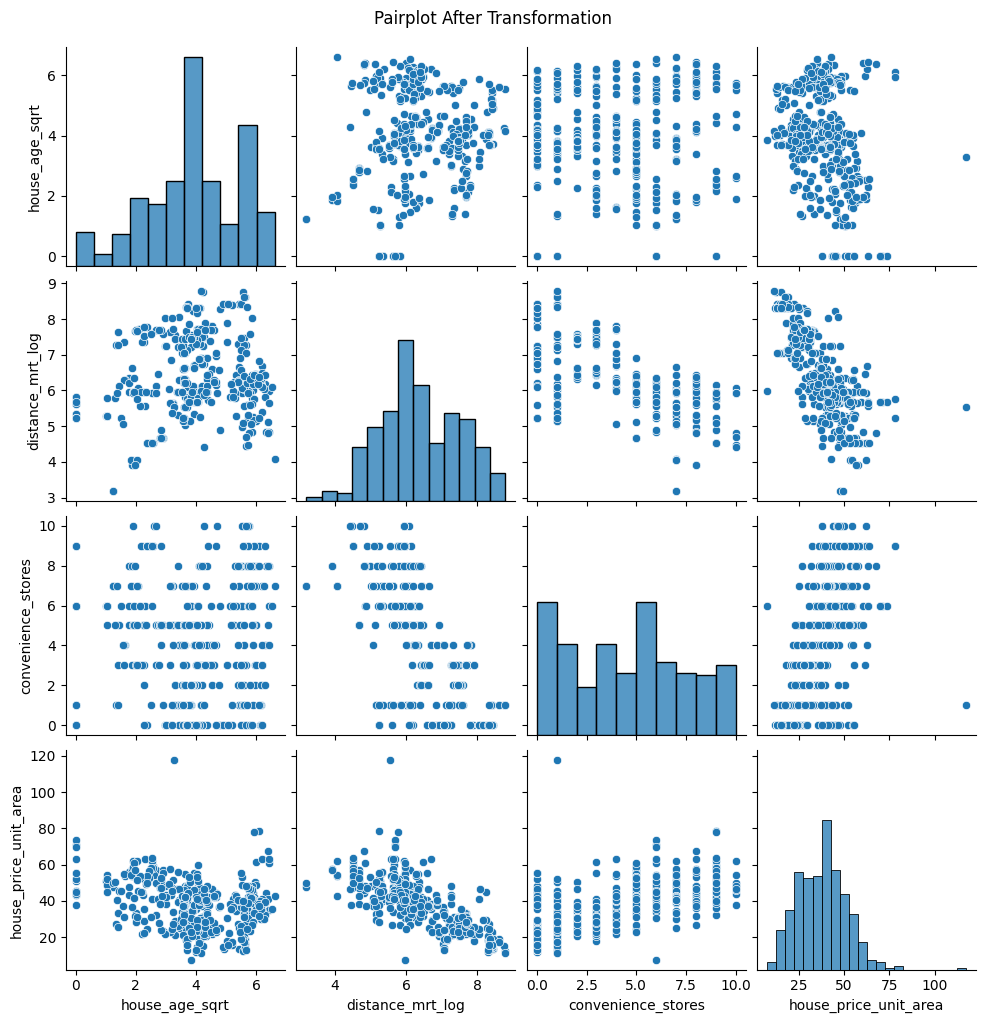

In [20]:
sns.pairplot(df_subset[['house_age_sqrt','distance_mrt_log','convenience_stores','house_price_unit_area']])
plt.suptitle('Pairplot After Transformation', y=1.02)
plt.show()

## 11. A Note on Geographic Features (Latitude / Longitude)
`latitude` and `longitude` describe *location*, and price doesn't vary linearly with coordinates — it depends on neighborhood-level patterns that a straight-line model can't really capture (two points close in coordinates can have very different prices depending on what's nearby). A **tree-based model** (Random Forest / Gradient Boosting) would generally handle this kind of spatial, non-linear signal better, since it can split the region into local pockets.

Since the goal here is a linear regression, I still kept `latitude`/`longitude` in the model rather than dropping them — excluding them would throw away real signal, and their coefficients are still informative directionally even if the linear fit isn't perfectly suited to spatial data.

## 12. Multiple Linear Regression
Features used: `house_age_sqrt`, `distance_mrt_log`, `convenience_stores`, `latitude`, `longitude`.
Target: `house_price_unit_area`.

In [21]:
features = ['house_age_sqrt', 'distance_mrt_log', 'convenience_stores', 'latitude', 'longitude']
target = 'house_price_unit_area'

X = df_subset[features]
y = df_subset[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

## 13. Model Evaluation — R², RMSE, MAE

In [22]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
n, p = X_test.shape[0], X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("---------------------------------------------")
print("Model Evaluation Metrics (Test Set)")
print("---------------------------------------------")
print(f"R-squared        : {r2:.4f}")
print(f"Adjusted R-squared: {adj_r2:.4f}")
print(f"RMSE              : {rmse:.4f}")
print(f"MAE               : {mae:.4f}")
#R^2 shows the proportion of variance in price explained by the model.
#RMSE and MAE are in the same units as house_price_unit_area, so they show the average prediction error directly.

---------------------------------------------
Model Evaluation Metrics (Test Set)
---------------------------------------------
R-squared        : 0.7080
Adjusted R-squared: 0.6890
RMSE              : 6.9992
MAE               : 4.7119


## 14. Coefficients (Slopes) & Interpretation
Using `statsmodels` OLS on the full dataset to get slope coefficients with p-values, since `sklearn` doesn't report significance directly.

In [23]:
X_sm = sm.add_constant(X)
ols_model = sm.OLS(y, X_sm).fit()
print(ols_model.summary())

                              OLS Regression Results                             
Dep. Variable:     house_price_unit_area   R-squared:                       0.645
Model:                               OLS   Adj. R-squared:                  0.640
Method:                    Least Squares   F-statistic:                     148.1
Date:                   Sun, 09 Aug 2026   Prob (F-statistic):           2.26e-89
Time:                           13:31:34   Log-Likelihood:                -1453.4
No. Observations:                    414   AIC:                             2919.
Df Residuals:                        408   BIC:                             2943.
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const 

In [24]:
coef_df = pd.DataFrame({
    'feature': ols_model.params.index,
    'coefficient': ols_model.params.values,
    'p_value': ols_model.pvalues.values
})
coef_df

,feature,coefficient,p_value
0,const,-10292.927125,1.449441e-02
1,house_age_sqrt,-1.927995,1.337826e-12
2,distance_mrt_log,-5.937528,4.656588e-21
3,convenience_stores,0.490063,1.148762e-02
4,latitude,295.209901,4.964942e-14
5,longitude,24.711730,4.800842e-01


**Slope interpretation (holding all other features constant):**
- `house_age_sqrt`: negative slope — as the transformed house age increases, price per unit area tends to fall; older properties sell for less.
- `distance_mrt_log`: negative slope — the further (log-scaled) a property is from the nearest MRT station, the lower its price; transit proximity is a strong price driver.
- `convenience_stores`: positive slope — each additional nearby convenience store is associated with a higher price, reflecting neighborhood walkability/amenity value.
- `latitude` / `longitude`: their coefficients capture a broad north-south / east-west price gradient across the district, but as noted above, a straight-line coefficient is a rough summary of what is really a non-linear spatial pattern.

*(Read the exact coefficient magnitudes and p-values from the table above — features with p-value < 0.05 are statistically significant predictors in this model.)*

## 15. Summary
- Cleaned and engineered date features from the raw transaction data.
- Explored yearly/monthly price trends and relationships with amenities.
- Applied `sqrt` and `log1p` transformations to reduce skew/non-linearity in `house_age` and `distance__mrt`.
- Noted that `latitude`/`longitude` are better suited to tree-based models, but kept them in the linear model for completeness.
- Fit a multiple linear regression and evaluated it with R², Adjusted R², RMSE, and MAE.
- Interpreted each feature's slope to explain its relationship with price.

**A companion interactive Tableau dashboard visualizes these trends geographically and over time.**